## The purpose of this noetbook is to explore the overall UK crime and IMD data

I will include some visualisations which explore this further

In [20]:
!pip install geopandas

   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/22.9 MB ? eta -:--:--
   - -------------------------------------- 1.0/22.9 MB 2.7 MB/s eta 0:00:09
   -- ------------------------------------- 1.6/22.9 MB 2.8 MB/s eta 0:00:08
   ---- ----------------------------------- 2.4/22.9 MB 3.1 MB/s eta 0:00:07
   ----- ---------------------------------- 3.4/22.9 MB 3.4 MB/s eta 0:00:06
   ------- -------------------------------- 4.5/22.9 MB 3.8 MB/s eta 0:00:05
   --------- ------------------------------ 5.5/22.9 MB 3.9 MB/s eta 0:00:05
   ---------- ----------------------------- 6.3/22.9 MB 4.0 MB/s eta 0:00:05
   ------------ --------------------------- 7.3/22.9 MB 4.1 MB/s eta 0:00:04
   ------------- -------------------------- 7.9/22.9 MB 4.0 MB/s eta 0:00:04
   ------------- -------------------------- 7.9/22.9 MB 4.0 MB/s eta 0:00:04
   --------------- ------------------------ 8.9/22.9 MB 3.8 MB/s eta 0:00:04
   ----------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import pandas as pd
import numpy as np
import statistics 
import openpyxl
import geopandas
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [88]:
crime_df = pd.read_csv("CLEANED-regional_forces_crime_data_2024-2025.csv")
imd_df = pd.read_csv("clean_index_of_multiple_deprivation.csv")

print(crime_df.columns)
print(imd_df.columns)


crime_df.rename(columns={"ITL1 region": "ITL1", "ITL2 region": "ITL2"}, inplace=True)
print(imd_df["ITL1"].tail(4))
print(crime_df["ITL1"].tail(4))

crime_df.replace("East Midlands", "East Midlands (England)", inplace=True)
crime_df.replace("West Midlands","West Midlands (England)", inplace=True)

# print(imd_df.head(5))

Index(['Unnamed: 0', 'Financial Year', 'Financial Quarter', 'Force Name',
       'Offence Description', 'Offence Group', 'Offence Subgroup',
       'Offence Code', 'Number of Offences', 'ITL1 region', 'ITL2 region'],
      dtype='str')
Index(['IMD Rank', 'IMD Decile', 'ITL1', 'ITL2'], dtype='str')
33751    South East (England)
33752    South East (England)
33753    South East (England)
33754    South East (England)
Name: ITL1, dtype: str
22460    South West (England)
22461    South West (England)
22462    South West (England)
22463    South West (England)
Name: ITL1, dtype: str


,Unnamed: 0,Financial Year,Financial Quarter,Force Name,Offence Description,Offence Group,Offence Subgroup,Offence Code,Number of Offences,ITL1,ITL2
0,0,2024/25,1,Avon and Somerset,Absconding from lawful custody,Miscellaneous crimes against society,Miscellaneous crimes against society,80,2,South West (England),"['West of England', 'North Somerset, Somerset ..."
1,1,2024/25,1,Avon and Somerset,Abuse of children through sexual exploitation,Sexual offences,Other sexual offences,71,4,South West (England),"['West of England', 'North Somerset, Somerset ..."
2,2,2024/25,1,Avon and Somerset,Abuse of position of trust of a sexual nature,Sexual offences,Other sexual offences,73,1,South West (England),"['West of England', 'North Somerset, Somerset ..."
3,3,2024/25,1,Avon and Somerset,Aggravated burglary - residential (home),Theft offences,Residential burglary,29B,26,South West (England),"['West of England', 'North Somerset, Somerset ..."
4,4,2024/25,1,Avon and Somerset,Aggravated burglary - residential (unconnected...,Theft offences,Residential burglary,29C,1,South West (England),"['West of England', 'North Somerset, Somerset ..."
...,...,...,...,...,...,...,...,...,...,...,...
22459,22459,2024/25,4,Wiltshire,Trafficking for sexual exploitation,Sexual offences,Other sexual offences,72,0,South West (England),['Gloucestershire and Wiltshire']
22460,22460,2024/25,4,Wiltshire,Trafficking in controlled drugs,Drug offences,Trafficking of drugs,92A,97,South West (England),['Gloucestershire and Wiltshire']
22461,22461,2024/25,4,Wiltshire,Unnatural sexual offences,Sexual offences,Other sexual offences,88D,0,South West (England),['Gloucestershire and Wiltshire']
22462,22462,2024/25,4,Wiltshire,Violent disorder,Public order offences,Public order offences,62A,2,South West (England),['Gloucestershire and Wiltshire']


In [96]:
data = crime_df.loc[:,"Number of Offences"]

def find_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data >
    upper_bound)]
    return f"Here are the outliers: {outliers}, the lower bound: {lower_bound} and the upper bounds {upper_bound}."

find_outliers_iqr(data)






'Here are the outliers: 13       3607\n16       4819\n17        386\n33        571\n47        620\n         ... \n22387     603\n22401     277\n22408     425\n22420     726\n22446     982\nName: Number of Offences, Length: 3206, dtype: int64, the lower bound: -165.375 and the upper bounds 275.625.'

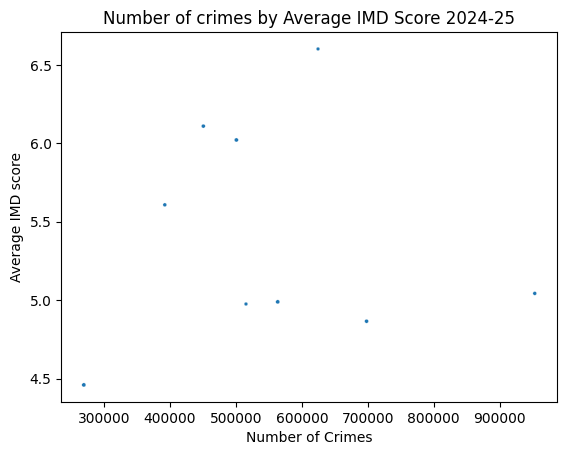

<Figure size 640x480 with 0 Axes>

In [ ]:

ITL1_grouped_crimes = crime_df.groupby("ITL1")["Number of Offences"].sum()
# print(ITL1_grouped_crimes)
number_of_crimes = crime_df.groupby("Offence Group")["Number of Offences"].sum()

avg_imd_by_ITL1 = imd_df.groupby("ITL1")["IMD Decile"].mean()
avg_imd_by_ITL2 = imd_df.groupby("ITL2")["IMD Decile"].mean()
IMD2_dict = avg_imd_by_ITL2.to_dict()
IMD_dict = avg_imd_by_ITL1.to_dict()
# print(ITL1_grouped_crimes)
# print(avg_imd_by_ITL1)

crime_df["IMD"] = crime_df["ITL1"].map(IMD_dict)

regional_summary = crime_df.groupby("ITL1").agg(
    total_offences = ("Number of Offences", "sum"),
    avg_imd_by_ITL1 =("IMD", "mean"))
#print(regional_summary)

regional_happiness = {"East (England)": 7.9, #Should pull this from the excel (sheet called "1.3_Happiness")
"East Midlands (England)": 7.5,
"London": 7.4,
"North East (England)": 8.7,
"North West (England)": 7.9,
"South East (England)": 6.6,
"South West (England)": 8.5,
"West Midlands (England)": 6.9,
"Yorkshire and The Humber": 8.6}

scores = [7.9, 7.5, 7.4, 8.7, 7.9, 6.6, 8.5,6.9,8.6 ]
np.array(scores)
log_scores = []
for score in scores:
    np.log10(scores)
    log_scores.append(score)

happy_series = pd.Series(regional_happiness)


# regional_summary= happy_df.merge(regional_summary)


# new_df = ITL1_grouped_crimes.add(avg_imd_by_ITL1)
# print(new_df)
sns.scatterplot(x="total_offences", y="avg_imd_by_ITL1", s=log_scores, data=regional_summary)
plt.xlabel("Number of Crimes")
plt.ylabel("Average IMD score")
plt.title("Number of crimes by Average IMD Score 2024-25")
plt.show()

#To add:
# Labels per region / a colour legend
# Try and do the sizing by some kind of wellness metric
# DO some logarithms to make it more spaced out

plt.tight_layout()


Index(['Unnamed: 0', 'Financial Year', 'Financial Quarter', 'Force Name',
       'Offence Description', 'Offence Group', 'Offence Subgroup',
       'Offence Code', 'Number of Offences', 'ITL1', 'ITL2', 'IMD',
       'IMD ITL2'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 22464 entries, 0 to 22463
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           22464 non-null  int64  
 1   Financial Year       22464 non-null  str    
 2   Financial Quarter    22464 non-null  int64  
 3   Force Name           22464 non-null  str    
 4   Offence Description  22464 non-null  str    
 5   Offence Group        22464 non-null  str    
 6   Offence Subgroup     22464 non-null  str    
 7   Offence Code         22464 non-null  str    
 8   Number of Offences   22464 non-null  int64  
 9   ITL1                 22464 non-null  str    
 10  ITL2                 22464 non-null  str    
 11 

Text(0.5, 1.0, 'Number of crimes by Average IMD Score 2024-25')

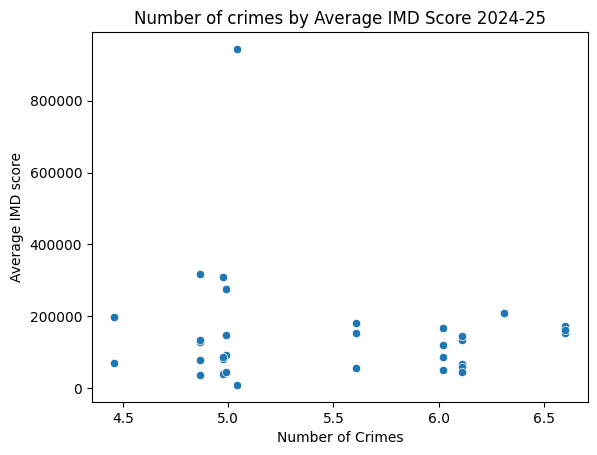

In [ ]:


ITL1_grouped_crimes = crime_df.groupby("ITL1")["Number of Offences"].sum()
number_of_crimes = crime_df.groupby("Offence Group")["Number of Offences"].sum()
# print(number_of_crimes)

avg_imd_by_ITL1 = imd_df.groupby("ITL1")["IMD Decile"].mean()
avg_imd_by_ITL2 = imd_df.groupby("ITL2")["IMD Decile"].mean()
IMD2_dict = avg_imd_by_ITL2.to_dict()
IMD_dict = avg_imd_by_ITL1.to_dict()
# print(IMD_dict)
print(crime_df.columns)
# Need to make a function that adds together the ITL2 regions IMD scores and finds the average among them

def find_avg_imd_score(crime_df, IMD2_dict):
    """
    This function allows me to explode the data, so I can map the regional score to the right ITL2 region and then will take an average of scores within that row.
    For example some Police Forces cover multiple ITL2 regions and therefore this is the most comprehensive, without going too broadly with the ITL1 regions
    """
    individual_ITL2 = crime_df[["Force Name","ITL2"]].explode("ITL2")
    ITL2_IMD_map = individual_ITL2.map(IMD2_dict)
    crime_df["IMD_avg"] = ITL2_IMD_map.groupby("Force Name")["IMD_score"].mean()
    return crime_df

crime_df["IMD ITL2"] = crime_df["ITL1"].map(IMD_dict)

crime_df.info()


regional_summary = crime_df.groupby("ITL2").agg(
    total_offences = ("Number of Offences", "sum"),
    avg_imd_by_ITL2 =("IMD ITL2", "mean"))




sns.scatterplot(x="avg_imd_by_ITL2", y="total_offences",  data=regional_summary)
plt.xlabel("Number of Crimes")
plt.ylabel("Average IMD score")
plt.title("Number of crimes by Average IMD Score 2024-25")

#TO do
# Try to see if there's any relationship between the two
